In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/features_disease_dataset.csv")
print(df.shape)
df.head()

(1040, 28)


,village_id,village_name,latitude,longitude,population,date,ph_level,turbidity_ntu,residual_chlorine_mg_l,bacterial_contamination,...,sanitation_gap,week_number,month,water_source_type_handpump,water_source_type_pond,water_source_type_river,disease_type_diarrhea,disease_type_hepatitis_a,disease_type_typhoid,outbreak_risk_level_encoded
0,V001,Village_1,16.57454,74.31185,10470,2024-01-07,6.84,1.95,0.456,0,...,0.66,1,1,False,True,False,True,False,False,2
1,V001,Village_1,16.57454,74.31185,10470,2024-01-14,7.33,2.31,0.462,0,...,0.66,2,1,False,True,False,False,False,True,2
2,V001,Village_1,16.57454,74.31185,10470,2024-01-21,5.94,2.49,0.326,0,...,0.66,3,1,False,True,False,True,False,False,1
3,V001,Village_1,16.57454,74.31185,10470,2024-01-28,6.58,1.78,0.382,0,...,0.66,4,1,False,True,False,False,False,False,0
4,V001,Village_1,16.57454,74.31185,10470,2024-02-04,6.99,2.84,0.274,0,...,0.66,5,2,False,True,False,False,True,False,1


In [2]:
target_column = "outbreak_risk_level_encoded"

drop_columns = ["village_id", "village_name", "date", "outbreak_risk_level",
                 "outbreak_risk_level_encoded", "case_count"]

X = df.drop(columns=drop_columns)
y = df[target_column]

print("Feature columns used:")
print(list(X.columns))
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Feature columns used:
['latitude', 'longitude', 'population', 'ph_level', 'turbidity_ntu', 'residual_chlorine_mg_l', 'bacterial_contamination', 'rainfall_mm', 'temperature_c', 'sanitation_index', 'historical_cases_last_4_weeks', 'water_quality_risk_score', 'environmental_risk_score', 'sanitation_gap', 'week_number', 'month', 'water_source_type_handpump', 'water_source_type_pond', 'water_source_type_river', 'disease_type_diarrhea', 'disease_type_hepatitis_a', 'disease_type_typhoid']

X shape: (1040, 22)
y shape: (1040,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (832, 22)
Test size: (208, 22)


In [4]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

train_accuracy = log_reg_model.score(X_train, y_train)
test_accuracy = log_reg_model.score(X_test, y_test)

print("Logistic Regression Train Accuracy:", round(train_accuracy, 3))
print("Logistic Regression Test Accuracy:", round(test_accuracy, 3))

Logistic Regression Train Accuracy: 0.685
Logistic Regression Test Accuracy: 0.673


k:\PRIME\ML\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

train_accuracy_rf = rf_model.score(X_train, y_train)
test_accuracy_rf = rf_model.score(X_test, y_test)

print("Random Forest Train Accuracy:", round(train_accuracy_rf, 3))
print("Random Forest Test Accuracy:", round(test_accuracy_rf, 3))

Random Forest Train Accuracy: 0.93
Random Forest Test Accuracy: 0.683


In [6]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

importances.head(10)

population                       0.178835
historical_cases_last_4_weeks    0.109344
turbidity_ntu                    0.087957
water_quality_risk_score         0.085587
sanitation_gap                   0.061224
sanitation_index                 0.053436
rainfall_mm                      0.051214
residual_chlorine_mg_l           0.050823
week_number                      0.045247
latitude                         0.042810
dtype: float64

In [7]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(log_reg_model, "models/logistic_regression_model.pkl")
joblib.dump(rf_model, "models/random_forest_model.pkl")

print("Models saved to 'models/' folder.")

Models saved to 'models/' folder.


MODEL EVALUTION

In [8]:
y_pred_log_reg = log_reg_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("Logistic Regression predictions (first 10):", y_pred_log_reg[:10])
print("Random Forest predictions (first 10):", y_pred_rf[:10])
print("Actual values (first 10):", y_test.values[:10])

Logistic Regression predictions (first 10): [2 1 2 1 1 2 0 0 1 2]
Random Forest predictions (first 10): [2 1 2 1 1 2 0 0 1 2]
Actual values (first 10): [2 2 2 1 1 2 0 0 0 1]


In [9]:
from sklearn.metrics import classification_report

print("LOGISTIC REGRESSION REPORT")
print(classification_report(y_test, y_pred_log_reg, target_names=["Low", "Medium", "High"]))

LOGISTIC REGRESSION REPORT
              precision    recall  f1-score   support

         Low       0.70      0.61      0.65        51
      Medium       0.53      0.59      0.55        70
        High       0.79      0.78      0.79        87

    accuracy                           0.67       208
   macro avg       0.67      0.66      0.66       208
weighted avg       0.68      0.67      0.68       208



In [10]:
print("RANDOM FOREST REPORT")
print(classification_report(y_test, y_pred_rf, target_names=["Low", "Medium", "High"]))

RANDOM FOREST REPORT
              precision    recall  f1-score   support

         Low       0.86      0.59      0.70        51
      Medium       0.57      0.56      0.56        70
        High       0.70      0.84      0.76        87

    accuracy                           0.68       208
   macro avg       0.71      0.66      0.67       208
weighted avg       0.69      0.68      0.68       208



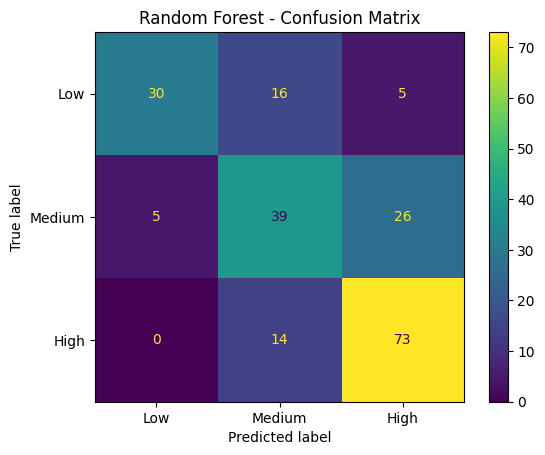

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=["Low", "Medium", "High"])
plt.title("Random Forest - Confusion Matrix")
plt.show()

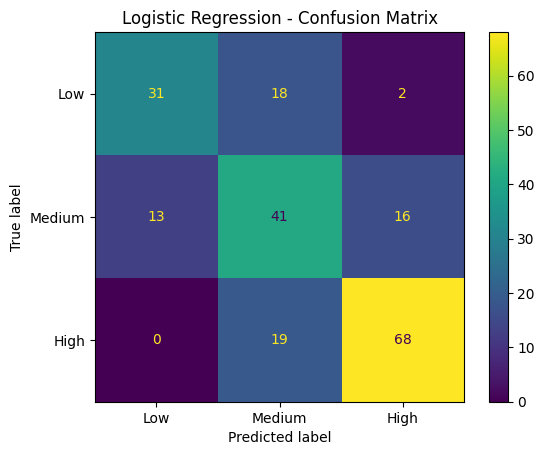

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log_reg, display_labels=["Low", "Medium", "High"])
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [13]:
from sklearn.metrics import accuracy_score, f1_score

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_log_reg), accuracy_score(y_test, y_pred_rf)],
    "F1 Score (weighted)": [f1_score(y_test, y_pred_log_reg, average="weighted"),
                             f1_score(y_test, y_pred_rf, average="weighted")]
})

comparison

,Model,Accuracy,F1 Score (weighted)
0,Logistic Regression,0.673077,0.675294
1,Random Forest,0.682692,0.679637


Disease-Risk Prediction

In [14]:
import joblib
import pandas as pd

rf_model = joblib.load("../models/random_forest_model.pkl")
print("Model loaded.")

Model loaded.


In [15]:
predictions = rf_model.predict(X_test)
probabilities = rf_model.predict_proba(X_test)

results = X_test.copy()
results["actual_risk"] = y_test.values
results["predicted_risk"] = predictions
results["confidence"] = probabilities.max(axis=1)

risk_mapping_reverse = {0: "Low", 1: "Medium", 2: "High"}
results["actual_risk_label"] = results["actual_risk"].map(risk_mapping_reverse)
results["predicted_risk_label"] = results["predicted_risk"].map(risk_mapping_reverse)

results[["actual_risk_label", "predicted_risk_label", "confidence"]].head(15)

,actual_risk_label,predicted_risk_label,confidence
39,High,High,0.790771
426,High,Medium,0.452920
17,High,High,0.631702
937,Medium,Medium,0.462309
880,Medium,Medium,0.559992
771,High,High,0.625909
224,Low,Low,0.482596
117,Low,Low,0.772890
499,Low,Medium,0.590814
450,Medium,High,0.762518


In [16]:
mismatches = results[results["actual_risk_label"] != results["predicted_risk_label"]]
print("Number of mismatches:", len(mismatches))
mismatches[["actual_risk_label", "predicted_risk_label", "confidence"]].head(10)

Number of mismatches: 66


,actual_risk_label,predicted_risk_label,confidence
426,High,Medium,0.452920
499,Low,Medium,0.590814
450,Medium,High,0.762518
675,High,Medium,0.473579
470,Medium,Low,0.772737
276,Medium,High,0.584301
451,Medium,High,0.550967
975,Low,Medium,0.564897
414,Low,Medium,0.568301
424,High,Medium,0.471774


In [17]:
new_reading = pd.DataFrame([{
    "latitude": 16.70, "longitude": 74.25, "population": 5000,
    "ph_level": 6.8, "turbidity_ntu": 8.5, "residual_chlorine_mg_l": 0.1,
    "bacterial_contamination": 1, "rainfall_mm": 45.0, "temperature_c": 27.0,
    "sanitation_index": 0.35, "historical_cases_last_4_weeks": 9,
    "water_quality_risk_score": (8.5/10) + (1-0.1) + 1.0,
    "environmental_risk_score": (45.0/50) + ((27.0-20)/15),
    "sanitation_gap": 1 - 0.35,
    "week_number": 26, "month": 7,
    "water_source_type_handpump": False, "water_source_type_pond": False, "water_source_type_river": True,
    "disease_type_diarrhea": False, "disease_type_hepatitis_a": False, "disease_type_typhoid": False
}])

# Ensure column order matches training data exactly
new_reading = new_reading[X_train.columns]
new_reading.head()

,latitude,longitude,population,ph_level,turbidity_ntu,residual_chlorine_mg_l,bacterial_contamination,rainfall_mm,temperature_c,sanitation_index,...,environmental_risk_score,sanitation_gap,week_number,month,water_source_type_handpump,water_source_type_pond,water_source_type_river,disease_type_diarrhea,disease_type_hepatitis_a,disease_type_typhoid
0,16.7,74.25,5000,6.8,8.5,0.1,1,45.0,27.0,0.35,...,1.366667,0.65,26,7,False,False,True,False,False,False


In [18]:
new_prediction = rf_model.predict(new_reading)[0]
new_probabilities = rf_model.predict_proba(new_reading)[0]

predicted_label = risk_mapping_reverse[new_prediction]
confidence = new_probabilities.max()

print("Predicted Risk Level:", predicted_label)
print("Confidence:", round(confidence, 3))
print("Full probability breakdown (Low, Medium, High):", new_probabilities)

Predicted Risk Level: High
Confidence: 0.895
Full probability breakdown (Low, Medium, High): [0.04083036 0.06459099 0.89457866]


SHAP

In [22]:
import shap

explainer = shap.TreeExplainer(rf_model)
print("Explainer created.")

Explainer created.


In [23]:
# import sys
# !{sys.executable} -m pip install shap

In [24]:
# import sys
# print(sys.executable)

# import shap
# print(shap.__version__)

In [25]:
shap_values = explainer.shap_values(X_test)

print("Type:", type(shap_values))
print("Shape:", shap_values.shape)

Type: <class 'numpy.ndarray'>
Shape: (208, 22, 3)


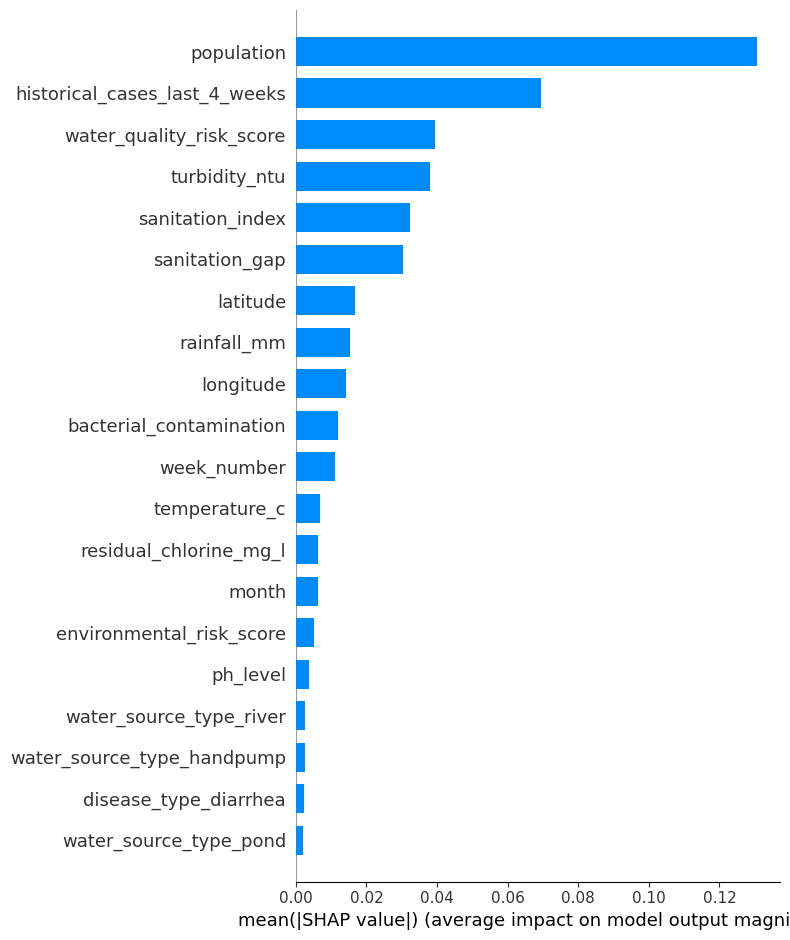

In [26]:
shap.summary_plot(shap_values[:, :, 2], X_test, plot_type="bar", show=True)

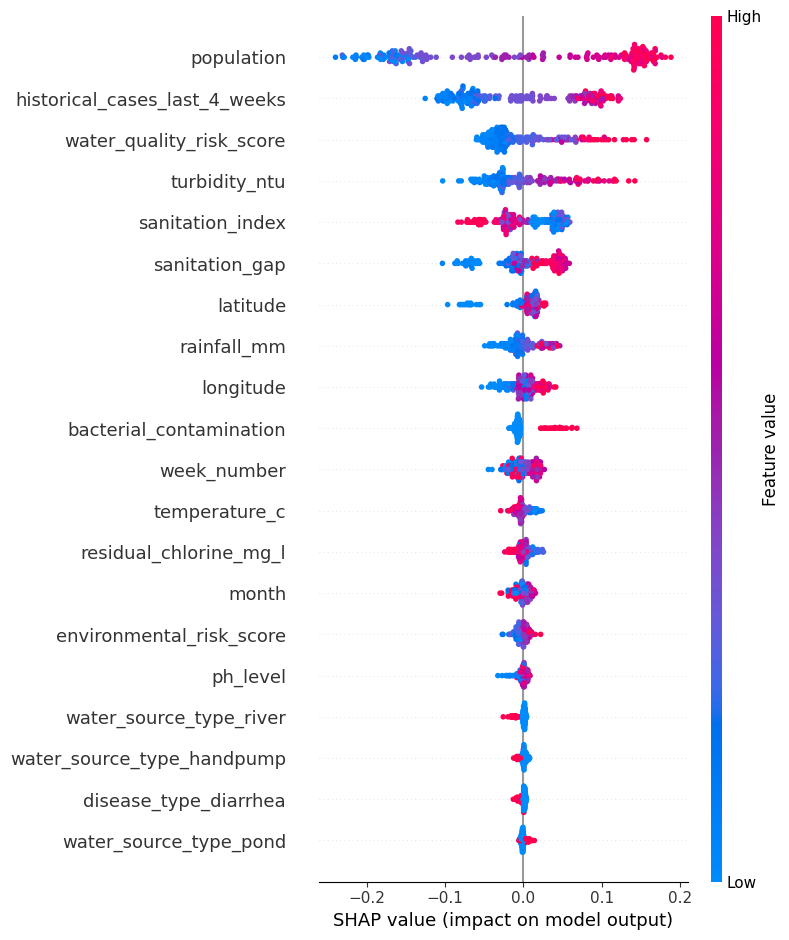

In [27]:
shap.summary_plot(shap_values[:, :, 2], X_test, show=True)

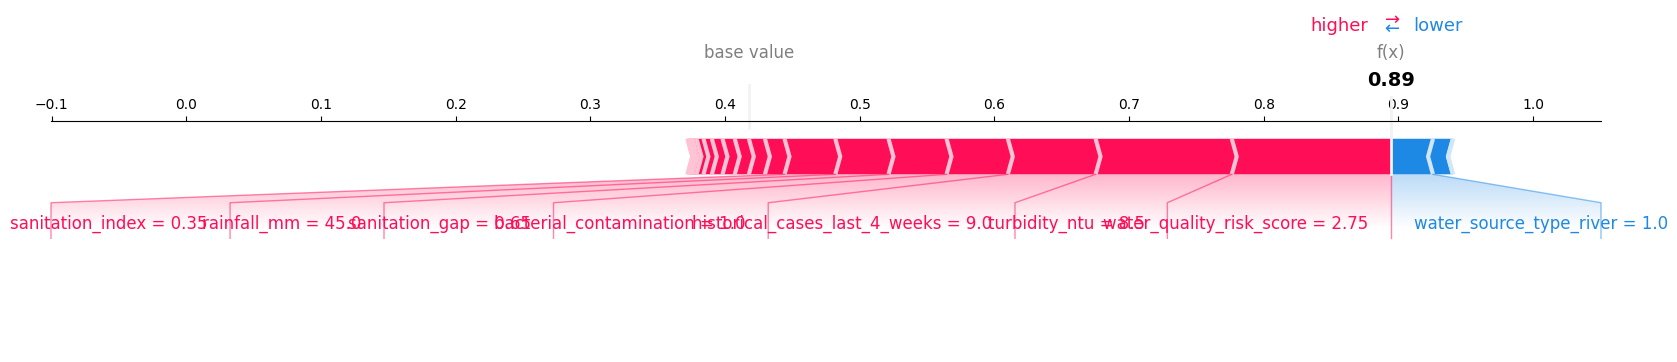

In [28]:
shap_values_new = explainer.shap_values(new_reading)

shap.force_plot(
    explainer.expected_value[2],
    shap_values_new[0, :, 2],
    new_reading.iloc[0],
    matplotlib=True,
    show=True
)

In [29]:
feature_names = list(X_test.columns)
contributions = shap_values_new[0, :, 2]

explanation_df = pd.DataFrame({
    "feature": feature_names,
    "shap_value": contributions
})

explanation_df["abs_value"] = explanation_df["shap_value"].abs()
explanation_df = explanation_df.sort_values(by="abs_value", ascending=False)

explanation_df[["feature", "shap_value"]].head(10)

,feature,shap_value
11,water_quality_risk_score,0.118300
4,turbidity_ntu,0.101103
10,historical_cases_last_4_weeks,0.065143
6,bacterial_contamination,0.045536
13,sanitation_gap,0.043068
7,rainfall_mm,0.039504
9,sanitation_index,0.037690
18,water_source_type_river,-0.031068
2,population,-0.014746
14,week_number,0.014564
